[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/almahova/iemocap-proj/blob/data-modelling/iemocap_modelling.ipynb)

# IEMOCAP Emotion Recognition Modelling Pipeline
## late fusion

This notebook implements a **late fusion model** for 3-class Speech Emotion Recognition (SER) on the IEMOCAP corpus.

| Component | Choice |
|-----------|--------|
| Model | `roberta-base` and `wav2vec2` fine-tuned for sequence classification |
| Split | Stratified 80 % train · 10 % val · 10 % test |
| Loss | Weighted Cross-Entropy (compensates ~55 % Negative imbalance) |
| Primary metric | **Macro F1-Score** |
| Classes | `Negative` (0) · `Positive` (1) · `Neutral` (2) |

## Approach

This notebook implements **late fusion** as a weighted sum of logits from two
independently fine-tuned models:

- **Text model** (`text_best_model_weights.pt`) `roberta-base` fine-tuned for
  3-class emotion classification.
- **Audio model** (`best_model.pt`) `facebook/wav2vec2-base` fine-tuned for
  3-class emotion classification, trained with **LOSO-CV** (Sessions 1-4 train,
  Session 5 held out as test).

To get a clean **1-to-1 matched test set** for both modalities, this notebook
evaluates on **Session 5 (`Ses05`)** the same held-out split used to train/evaluate
the audio model.

Final logits are combined as:

```
Final Logits = 0.45 * text_logits + 0.55 * audio_logits
```

In [1]:
import os
import io
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
import torchaudio.transforms as T

from torch.utils.data import Dataset, DataLoader
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    Wav2Vec2Processor,
    Wav2Vec2ForSequenceClassification,
)
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
)
from datasets import load_dataset
from tqdm import tqdm

# ── Device — CUDA > MPS (Apple Silicon) > CPU ────────────────────────────────
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device : {device}")
print(f"PyTorch: {torch.__version__}")

Device : cuda
PyTorch: 2.11.0+cu128


In [2]:
# ── All hyperparameters in one place change here, nowhere else ──────────────
CONFIG = {
    "text_model_name":  "roberta-base",
    "audio_model_name": "facebook/wav2vec2-base",
    "max_length":       128,     # text tokenizer max length
    "max_duration":     8.5,     # audio seconds — 90th percentile of IEMOCAP utterance durations
    "target_sr":        16_000,  # Hz required by Wav2Vec2
    "batch_size":       16,
    "num_labels":       3,
    "test_session":     5,       # Ses05 held out as test set
    "alpha_text":       0.45,
    "alpha_audio":      0.55,
    "random_seed":      42,
}

LABEL2ID = {"Negative": 0, "Positive": 1, "Neutral": 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}
CLASS_NAMES = ["Negative", "Positive", "Neutral"]

EMOTION_GROUP_MAP = {
    "happy":      "Positive",
    "excited":    "Positive",
    "angry":      "Negative",
    "frustrated": "Negative",
    "fear":       "Negative",
    "sad":        "Negative",
    "disgust":    "Negative",
    "other":      "Neutral",
    "neutral":    "Neutral",
    "surprise":   "Neutral",
}

# ── Checkpoint locations — Google Drive in Colab, ~/Downloads locally ─────────
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    CHECKPOINT_DIR = "/content/drive/MyDrive"
else:
    CHECKPOINT_DIR = os.path.expanduser("~/Downloads")

# ── Checkpoint locations ─────────

TEXT_CKPT_PATH = "/content/drive/MyDrive/Group1-Chen-Alma-Ohad/Sprint 3/text_best_model_weights.pt"

AUDIO_CKPT_PATH = "/content/drive/MyDrive/Group1-Chen-Alma-Ohad/Sprint 3/best_model.pt"

torch.manual_seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])

Mounted at /content/drive


---
## 1. Load Dataset & Build LOSO `Ses05` Test Set

In [3]:
ds = load_dataset("AbstractTTS/IEMOCAP")
df = ds["train"].to_pandas()

df["emotion_group"] = df["major_emotion"].map(EMOTION_GROUP_MAP)
# df = df.dropna(subset=["emotion_group", "transcription", "audio"]).reset_index(drop=True)
df["label"] = df["emotion_group"].map(LABEL2ID)

# Extract integer session number (1-5) for LOSO split
df["session_num"] = df["file"].str.extract(r"Ses(\d{2})").astype(int)

test_df = df[df["session_num"] == CONFIG["test_session"]].reset_index(drop=True)

print(f"Ses{CONFIG['test_session']:02d} test set: {len(test_df)} samples")
print(test_df["emotion_group"].value_counts().to_string())

README.md:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/489M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/456M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/462M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10039 [00:00<?, ? examples/s]

Ses05 test set: 2170 samples
emotion_group
Negative    1149
Positive     613
Neutral      408


In [4]:
# === Sum-then-Argmax: corrected ground truth + human-consensus score ===
group_emotions = {
    'Positive': ['happy', 'excited'],
    'Negative': ['angry', 'frustrated', 'fear', 'sad', 'disgust'],
    'Neutral':  ['neutral', 'surprise'],
}
for group, cols in group_emotions.items():
    test_df[f'{group}_prob'] = test_df[cols].sum(axis=1)

prob_cols = [f'{g}_prob' for g in group_emotions]
test_df['Corrected_Ground_Truth'] = test_df[prob_cols].idxmax(axis=1).str.replace('_prob', '', regex=False)
test_df['consensus']       = test_df[prob_cols].max(axis=1)
test_df['corrected_label'] = test_df['Corrected_Ground_Truth'].map(LABEL2ID)

print("Corrected_Ground_Truth distribution (Ses05 test set):")
print(test_df['Corrected_Ground_Truth'].value_counts().to_string())
print(f"\nMean human consensus: {test_df['consensus'].mean():.4f}")

n_flipped = (test_df['emotion_group'] != test_df['Corrected_Ground_Truth']).sum()
print(f"Labels flipped vs. major_emotion grouping: {n_flipped} / {len(test_df)} ({n_flipped/len(test_df)*100:.2f}%)")


Corrected_Ground_Truth distribution (Ses05 test set):
Corrected_Ground_Truth
Negative    1180
Positive     593
Neutral      397

Mean human consensus: 0.8103
Labels flipped vs. major_emotion grouping: 92 / 2170 (4.24%)


---
## 2. Datasets & DataLoaders

Both modalities are built from the **same `test_df`** with `shuffle=False`, so row `i` of the text loader corresponds to row `i` of the audio loader this guarantees 1-to-1 alignment for late fusion.

In [5]:
class IEMOCAPTextDataset(Dataset):
    """PyTorch Dataset that tokenises transcription text for RoBERTa."""

    def __init__(self, texts: list, labels: list, tokenizer, max_length: int):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict:
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }


class IEMOCAPDataset(Dataset):
    """PyTorch Dataset for IEMOCAP audio emotion classification (Wav2Vec2)."""

    def __init__(self, df, processor, max_duration, target_sr):
        self.df         = df.reset_index(drop=True)
        self.processor  = processor
        self.max_length = int(max_duration * target_sr)
        self.target_sr  = target_sr

    def __len__(self):
        return len(self.df)

    def _load_audio(self, audio_data):
        raw_bytes = audio_data.get("bytes")
        waveform, sr = sf.read(io.BytesIO(raw_bytes), dtype="float32")
        if waveform.ndim > 1:
            waveform = waveform.mean(axis=-1)
        return waveform, sr

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        waveform, sr = self._load_audio(row["audio"])

        if sr != self.target_sr:
            waveform_t = torch.from_numpy(waveform).unsqueeze(0)
            resampler  = T.Resample(orig_freq=sr, new_freq=self.target_sr)
            waveform   = resampler(waveform_t).squeeze(0).numpy()

        encoded = self.processor(
            waveform,
            sampling_rate=self.target_sr,
            return_tensors="pt",
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
        )

        return {
            "input_values": encoded["input_values"].squeeze(0),
            "attention_mask": encoded.get(
                "attention_mask", torch.ones(self.max_length)
            ).squeeze(0),
            "labels": torch.tensor(row["label"], dtype=torch.long),
        }


text_tokenizer  = RobertaTokenizer.from_pretrained(CONFIG["text_model_name"])
audio_processor = Wav2Vec2Processor.from_pretrained(CONFIG["audio_model_name"])

text_test_ds = IEMOCAPTextDataset(
    texts=test_df["transcription"].tolist(),
    labels=test_df["label"].tolist(),
    tokenizer=text_tokenizer,
    max_length=CONFIG["max_length"],
)
audio_test_ds = IEMOCAPDataset(
    test_df, audio_processor,
    max_duration=CONFIG["max_duration"], target_sr=CONFIG["target_sr"],
)

text_loader  = DataLoader(text_test_ds,  batch_size=CONFIG["batch_size"], shuffle=False)
audio_loader = DataLoader(audio_test_ds, batch_size=CONFIG["batch_size"], shuffle=False)

print(f"Batches text: {len(text_loader)} | audio: {len(audio_loader)}")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

Batches text: 136 | audio: 136


---
## 3. Load Pretrained Models

In [6]:
text_model = RobertaForSequenceClassification.from_pretrained(
    CONFIG["text_model_name"],
    num_labels=CONFIG["num_labels"],
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
text_model.load_state_dict(torch.load(TEXT_CKPT_PATH, map_location=device))
text_model.to(device).eval()

audio_model = Wav2Vec2ForSequenceClassification.from_pretrained(
    CONFIG["audio_model_name"],
    num_labels=CONFIG["num_labels"],
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)
audio_model.load_state_dict(torch.load(AUDIO_CKPT_PATH, map_location=device))
audio_model.freeze_feature_encoder()
audio_model.to(device).eval()

print("Both models loaded.")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_hid.bias             | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
classifier.weight            | MISSING    | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 
projector.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Both models loaded.


---
## 4. Inference Extract Logits

In [7]:
@torch.no_grad()
def extract_text_logits(model, loader, device):
    all_logits, all_labels = [], []
    for batch in tqdm(loader, desc="text inference"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"]

        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        all_logits.append(logits.cpu())
        all_labels.append(labels)
    return torch.cat(all_logits), torch.cat(all_labels)


@torch.no_grad()
def extract_audio_logits(model, loader, device):
    all_logits, all_labels = [], []
    for batch in tqdm(loader, desc="audio inference"):
        input_values = batch["input_values"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"]

        logits = model(input_values=input_values, attention_mask=attention_mask).logits
        all_logits.append(logits.cpu())
        all_labels.append(labels)
    return torch.cat(all_logits), torch.cat(all_labels)


text_logits,  text_labels  = extract_text_logits(text_model, text_loader, device)
audio_logits, audio_labels = extract_audio_logits(audio_model, audio_loader, device)

# Both loaders are built from the same test_df with shuffle=False, so row order
# must be identical verify before fusing.
assert torch.equal(text_labels, audio_labels), "Row order mismatch between text and audio loaders!"
true_labels = text_labels.numpy()

print(f"text_logits : {tuple(text_logits.shape)}")
print(f"audio_logits: {tuple(audio_logits.shape)}")

audio inference: 100%|██████████| 136/136 [01:23<00:00,  1.62it/s]

text_logits : (2170, 3)
audio_logits: (2170, 3)


---
## 5. Late Fusion Weighted Logit Sum

In [8]:
fused_logits = (CONFIG["alpha_text"] * text_logits) + (CONFIG["alpha_audio"] * audio_logits)
fused_probs  = torch.softmax(fused_logits, dim=-1).numpy()
fused_preds  = fused_logits.argmax(dim=-1).numpy()

# Single-modality predictions for comparison
text_preds  = text_logits.argmax(dim=-1).numpy()
audio_preds = audio_logits.argmax(dim=-1).numpy()

---
## 6. Evaluation

In [9]:
def report(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    print(f"\n=== {name} ===")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Macro F1:    {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))
    return acc, macro_f1, weighted_f1


report("Text-only (Ses05)",  true_labels, text_preds)
report("Audio-only (Ses05)", true_labels, audio_preds)


=== Text-only (Ses05) ===
Accuracy:    0.6843
Macro F1:    0.6475
Weighted F1: 0.6937
              precision    recall  f1-score   support

    Negative       0.81      0.72      0.76      1149
    Positive       0.73      0.70      0.72       613
     Neutral       0.40      0.54      0.46       408

    accuracy                           0.68      2170
   macro avg       0.65      0.66      0.65      2170
weighted avg       0.71      0.68      0.69      2170


=== Audio-only (Ses05) ===
Accuracy:    0.6829
Macro F1:    0.6398
Weighted F1: 0.6876
              precision    recall  f1-score   support

    Negative       0.80      0.77      0.78      1149
    Positive       0.68      0.59      0.63       613
     Neutral       0.45      0.58      0.51       408

    accuracy                           0.68      2170
   macro avg       0.64      0.65      0.64      2170
weighted avg       0.70      0.68      0.69      2170



(0.6829493087557603, 0.6397888334001797, 0.6875866251412133)

---
## 6b. Fusion Weight Search

Sweep `α_text` from 0.0 to 1.0 in steps of 0.05 (with `α_audio = 1 − α_text`) and record
Macro F1 for each combination. The best α is marked on the plot.
No new inference is needed — this reuses the `text_logits` and `audio_logits` already computed above.

In [10]:
import numpy as np

alphas = np.round(np.arange(0.0, 1.01, 0.05), 2)

search_results = []
for alpha in alphas:
    fused = alpha * text_logits + (1 - alpha) * audio_logits
    preds = fused.argmax(dim=-1).numpy()
    macro   = f1_score(true_labels, preds, average='macro')
    per_cls = f1_score(true_labels, preds, average=None, labels=[0, 1, 2])
    search_results.append({
        'alpha_text':  alpha,
        'alpha_audio': round(1 - alpha, 2),
        'macro_f1':    round(macro, 4),
        'neg_f1':      round(per_cls[0], 4),
        'pos_f1':      round(per_cls[1], 4),
        'neu_f1':      round(per_cls[2], 4),
    })

search_df = pd.DataFrame(search_results)
best      = search_df.loc[search_df['macro_f1'].idxmax()]

print(f"Best α_text  : {best['alpha_text']:.2f}  (α_audio = {best['alpha_audio']:.2f})")
print(f"Best Macro F1: {best['macro_f1']:.4f}")
print()
print(search_df.to_string(index=False))

Best α_text  : 0.45  (α_audio = 0.55)
Best Macro F1: 0.7108

 alpha_text  alpha_audio  macro_f1  neg_f1  pos_f1  neu_f1
       0.00         1.00    0.6398  0.7825  0.6299  0.5070
       0.05         0.95    0.6441  0.7864  0.6346  0.5112
       0.10         0.90    0.6499  0.7897  0.6439  0.5160
       0.15         0.85    0.6591  0.7938  0.6614  0.5220
       0.20         0.80    0.6673  0.7998  0.6782  0.5238
       0.25         0.75    0.6772  0.8053  0.6960  0.5303
       0.30         0.70    0.6874  0.8142  0.7151  0.5328
       0.35         0.65    0.6966  0.8219  0.7324  0.5356
       0.40         0.60    0.7038  0.8266  0.7430  0.5418
       0.45         0.55    0.7108  0.8249  0.7561  0.5514
       0.50         0.50    0.7051  0.8183  0.7617  0.5354
       0.55         0.45    0.6964  0.8119  0.7614  0.5159
       0.60         0.40    0.6957  0.8116  0.7593  0.5163
       0.65         0.35    0.6943  0.8105  0.7539  0.5184
       0.70         0.30    0.6880  0.8034  0.7446  0.

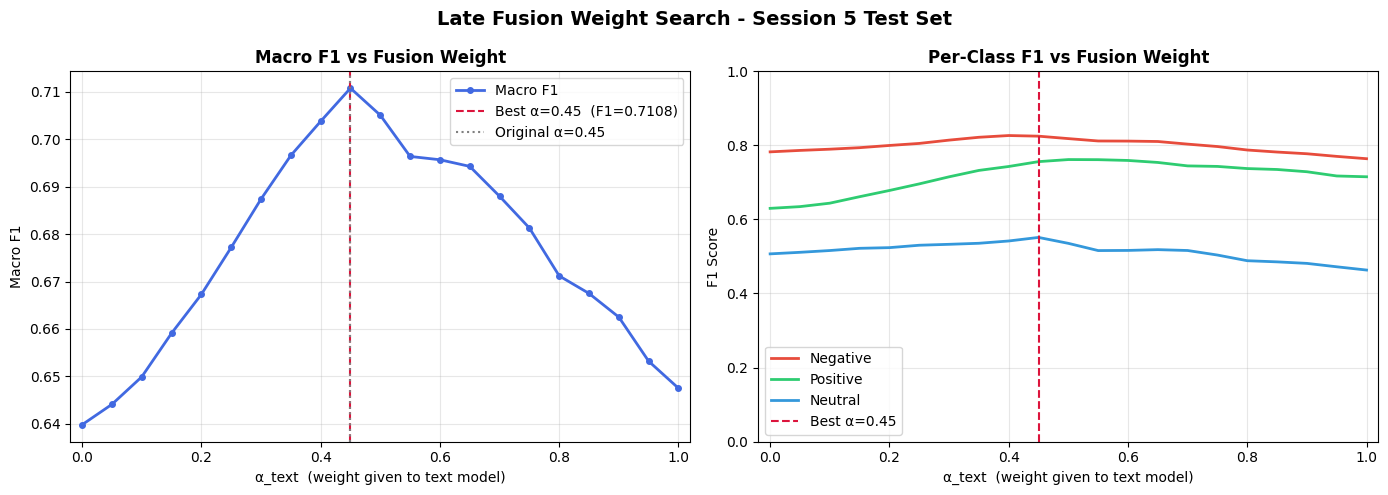

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Macro F1 vs α_text ──────────────────────────────────────────────
axes[0].plot(search_df['alpha_text'], search_df['macro_f1'],
             color='royalblue', linewidth=2, marker='o', markersize=4, label='Macro F1')
axes[0].axvline(best['alpha_text'], color='crimson', linestyle='--', linewidth=1.5,
                label=f"Best α={best['alpha_text']:.2f}  (F1={best['macro_f1']:.4f})")
axes[0].axvline(CONFIG['alpha_text'], color='gray', linestyle=':', linewidth=1.5,
                label=f"Original α={CONFIG['alpha_text']}")
axes[0].set_xlabel('α_text  (weight given to text model)')
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Macro F1 vs Fusion Weight', fontsize=12, weight='bold')
axes[0].legend()
axes[0].set_xlim(-0.02, 1.02)
axes[0].grid(alpha=0.3)

# ── Right: per-class F1 vs α_text ────────────────────────────────────────
axes[1].plot(search_df['alpha_text'], search_df['neg_f1'],
             color='#e74c3c', linewidth=2, label='Negative')
axes[1].plot(search_df['alpha_text'], search_df['pos_f1'],
             color='#2ecc71', linewidth=2, label='Positive')
axes[1].plot(search_df['alpha_text'], search_df['neu_f1'],
             color='#3498db', linewidth=2, label='Neutral')
axes[1].axvline(best['alpha_text'], color='crimson', linestyle='--', linewidth=1.5,
                label=f"Best α={best['alpha_text']:.2f}")
axes[1].set_xlabel('α_text  (weight given to text model)')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Per-Class F1 vs Fusion Weight', fontsize=12, weight='bold')
axes[1].legend()
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(0, 1.0)
axes[1].grid(alpha=0.3)

plt.suptitle('Late Fusion Weight Search - Session 5 Test Set', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

### Observations

The left plot shows how overall **Macro F1** changes as we vary the fusion weight α from audio-only (α=0.0) to text-only (α=1.0). The performance increases and reaches a clear peak around **α ≈ 0.45** (Macro F1 ≈ 0.7108), indicating that the text model contributes more strongly than the audio model, but optimal performance is achieved only when both modalities are combined.

The right plot shows per-class F1 behavior across different fusion weights:
*   The **Neutral** class benefits the most from increasing text weight, showing a strong improvement compared to audio-only.
*   The **Negative** class remains relatively stable across all α values.
*   The **Positive** class improves up to the optimal region and slightly decreases afterward.

At the extremes (α=0.0 and α=1.0), the results correspond to the standalone audio-only and text-only models respectively, confirming that the fusion implementation is consistent and correct.

There is a relatively flat performance region around the optimum (approximately **α ∈ [0.5, 0.7]**), indicating that the model is not highly sensitive to the exact fusion weight within this range and maintains near-optimal performance.

---
## 6c. Corrected Ground-Truth Evaluation (Sum-then-Argmax)

Re-evaluates the predictions already computed above (`text_preds`, `audio_preds`, `fused_preds`) against the corrected ground truth — no new inference, no retraining. Also reports the Consensus Tier Table for all three models in one place: accuracy/F1 stratified by how much annotators agreed on each utterance's grouped label.

In [12]:
def corrected_eval_report(test_df, y_pred, model_name="Model"):
    """Compare old vs. corrected Macro F1, and break down performance by human-consensus tier."""
    y_pred = np.array(y_pred)
    y_true_old       = test_df['label'].values
    y_true_corrected = test_df['corrected_label'].values

    old_f1 = f1_score(y_true_old, y_pred, average='macro')
    new_f1 = f1_score(y_true_corrected, y_pred, average='macro')
    print(f"=== {model_name} ===")
    print(f"Old Macro F1       (major_emotion GT)   : {old_f1:.4f}")
    print(f"Corrected Macro F1 (Sum-then-Argmax GT) : {new_f1:.4f}  (Δ {new_f1 - old_f1:+.4f})")

    bins = [0, 0.5, 0.75, 1.0]
    tier_labels = ['Low (<0.5)', 'Medium (0.5-0.75)', 'High (>0.75)']
    tiers = pd.cut(test_df['consensus'], bins=bins, labels=tier_labels, include_lowest=True)

    rows = []
    for tier in tier_labels:
        mask = (tiers == tier).values
        if mask.sum() == 0:
            continue
        rows.append({
            'Tier': tier, 'N': int(mask.sum()),
            'Accuracy': accuracy_score(y_true_corrected[mask], y_pred[mask]),
            'Macro F1': f1_score(y_true_corrected[mask], y_pred[mask], average='macro'),
        })
    tier_table = pd.DataFrame(rows)
    print(tier_table.to_string(index=False))
    print()
    return old_f1, new_f1, tier_table

In [13]:
# No retraining, no new inference — reuses text_preds / audio_preds / fused_preds computed above.
_ = corrected_eval_report(test_df, text_preds,  "Text-only")
_ = corrected_eval_report(test_df, audio_preds, "Audio-only")
_ = corrected_eval_report(test_df, fused_preds, "Late Fusion")

=== Text-only ===
Old Macro F1       (major_emotion GT)   : 0.6475
Corrected Macro F1 (Sum-then-Argmax GT) : 0.6506  (Δ +0.0031)
             Tier    N  Accuracy  Macro F1
       Low (<0.5)   65  0.307692  0.285416
Medium (0.5-0.75)  940  0.585106  0.587510
     High (>0.75) 1165  0.792275  0.694948

=== Audio-only ===
Old Macro F1       (major_emotion GT)   : 0.6398
Corrected Macro F1 (Sum-then-Argmax GT) : 0.6359  (Δ -0.0039)
             Tier    N  Accuracy  Macro F1
       Low (<0.5)   65  0.369231  0.307838
Medium (0.5-0.75)  940  0.595745  0.579780
     High (>0.75) 1165  0.768240  0.665994

=== Late Fusion ===
Old Macro F1       (major_emotion GT)   : 0.7108
Corrected Macro F1 (Sum-then-Argmax GT) : 0.7081  (Δ -0.0028)
             Tier    N  Accuracy  Macro F1
       Low (<0.5)   65  0.384615  0.344235
Medium (0.5-0.75)  940  0.647872  0.644609
     High (>0.75) 1165  0.850644  0.766093



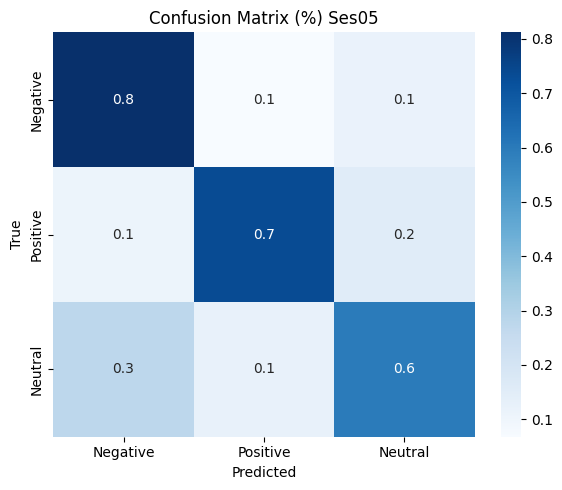

In [17]:
cm = confusion_matrix(true_labels, fused_preds)

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix (%) Ses{CONFIG['test_session']:02d}")
plt.tight_layout()
plt.show()

---
## 7. Save Predictions

In [15]:
results_df = pd.DataFrame({
    "file": test_df["file"],
    "true_label": true_labels,
    "true_emotion": [ID2LABEL[l] for l in true_labels],
    "text_pred": text_preds,
    "audio_pred": audio_preds,
    "fused_pred": fused_preds,
    "fused_emotion": [ID2LABEL[p] for p in fused_preds],
    "prob_negative": fused_probs[:, 0],
    "prob_positive": fused_probs[:, 1],
    "prob_neutral":  fused_probs[:, 2],
})
results_df.to_csv("late_fusion_predictions.csv", index=False)
print("Saved late_fusion_predictions.csv")
results_df.head()

Saved late_fusion_predictions.csv


,file,true_label,true_emotion,text_pred,audio_pred,fused_pred,fused_emotion,prob_negative,prob_positive,prob_neutral
0,Ses05F_impro01_F000.wav,2,Neutral,0,0,0,Negative,0.916860,0.008442,0.074698
1,Ses05F_impro01_F001.wav,0,Negative,0,2,0,Negative,0.773295,0.024561,0.202144
2,Ses05F_impro01_F002.wav,0,Negative,0,0,0,Negative,0.938335,0.009188,0.052478
3,Ses05F_impro01_F003.wav,0,Negative,0,0,0,Negative,0.880024,0.008479,0.111497
4,Ses05F_impro01_F004.wav,0,Negative,0,0,0,Negative,0.893483,0.008784,0.097733
